# Spotify — Historical Audio Feature Trends

This notebook tracks how danceability, energy, valence, acousticness, and BPM have evolved across the all-time top 100 and 2025's top 50.

---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Setup & Data Loading

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df_at = pd.read_csv('/content/drive/MyDrive/Kaggle/Spotify/Spotify_Songs_Data/spotify_alltime_top100_songs.csv')
df_art = pd.read_csv('/content/drive/MyDrive/Kaggle/Spotify/Spotify_Songs_Data/spotify_wrapped_2025_top50_artists.csv')
df_25 = pd.read_csv('/content/drive/MyDrive/Kaggle/Spotify/Spotify_Songs_Data/spotify_wrapped_2025_top50_songs.csv')

print(f'All-time top 100 : {df_at.shape[0]} songs | {df_at.release_year.min()} to {df_at.release_year.max()}')
print(f'2025 Wrapped top 50: {df_25.shape[0]} songs')
print(f'2025 Wrapped artists: {df_art.shape[0]} artists')

All-time top 100 : 100 songs | 1985 to 2024
2025 Wrapped top 50: 50 songs
2025 Wrapped artists: 50 artists


## 2. Decade-Level Overview

In [23]:
features = ['danceability', 'energy', 'valence', 'acousticness']

df_at['decade'] = (df_at['release_year'] // 10 * 10).astype(str) + 's'
decade_means = df_at.groupby('decade')[features + ['bpm']].mean().round(3)

print('Mean audio features by decade (all-time top 100)')
decade_means.style.background_gradient(axis=0)

Mean audio features by decade (all-time top 100)


,danceability,energy,valence,acousticness,bpm
decade,,,,,
1980s,0.410000,0.680000,0.250000,0.080000,112.000000
1990s,0.498000,0.650000,0.555000,0.320000,120.750000
2000s,0.468000,0.798000,0.242000,0.015000,126.750000
2010s,0.609000,0.606000,0.526000,0.171000,115.167000
2020s,0.654000,0.659000,0.628000,0.126000,115.054000


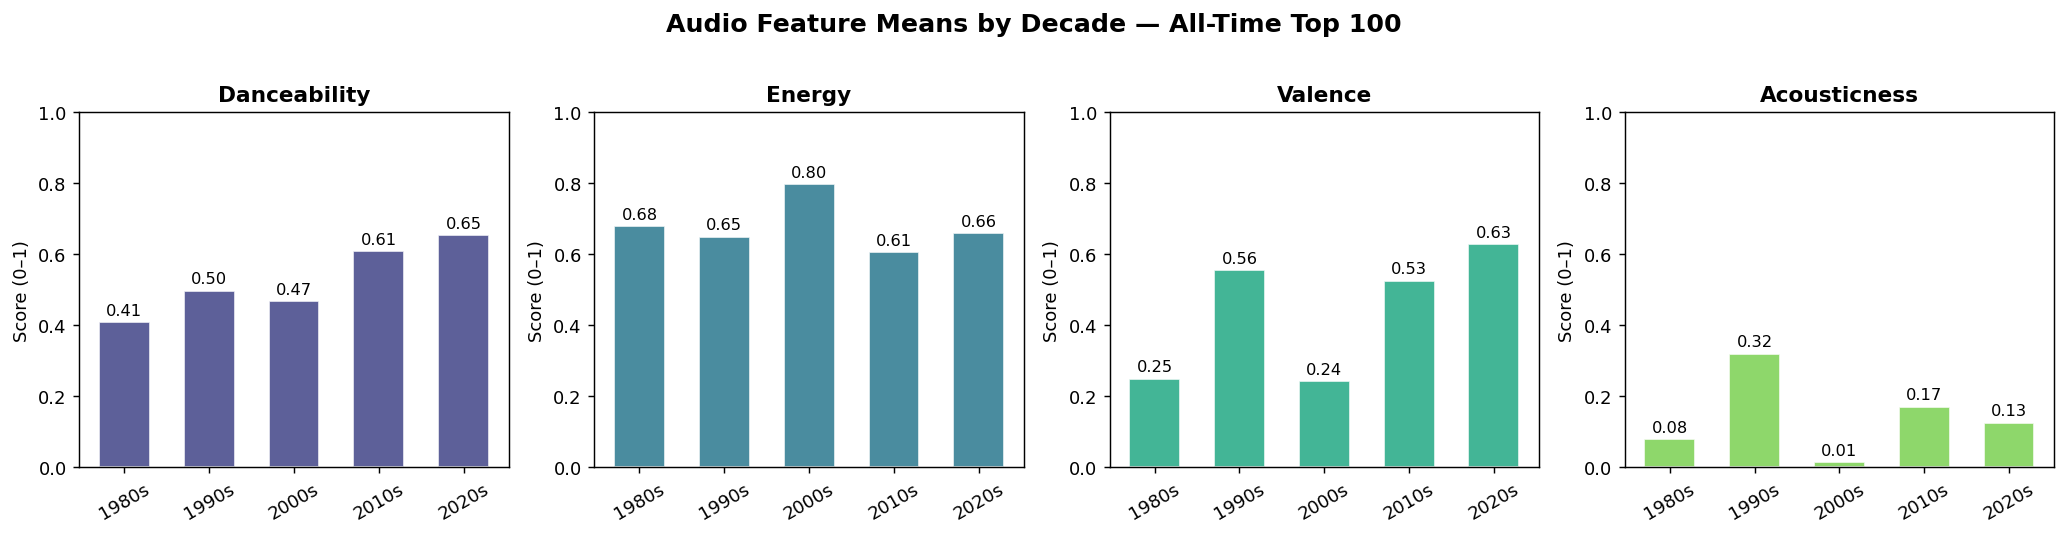

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Audio Feature Means by Decade — All-Time Top 100', fontsize=14, fontweight='bold', y=1.02)

# Generate a general color palette using seaborn
general_colors = sns.color_palette('viridis', n_colors=len(features))

for ax, feat, color in zip(axes, features, general_colors):
    vals = decade_means[feat]
    bars = ax.bar(vals.index, vals.values, color=color, alpha=0.85, edgecolor='white', width=0.6)
    ax.set_title(feat.capitalize(), fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score (0–1)')
    ax.tick_params(axis='x', rotation=30)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 3. Year-by-Year Trend Lines (2012–2024)

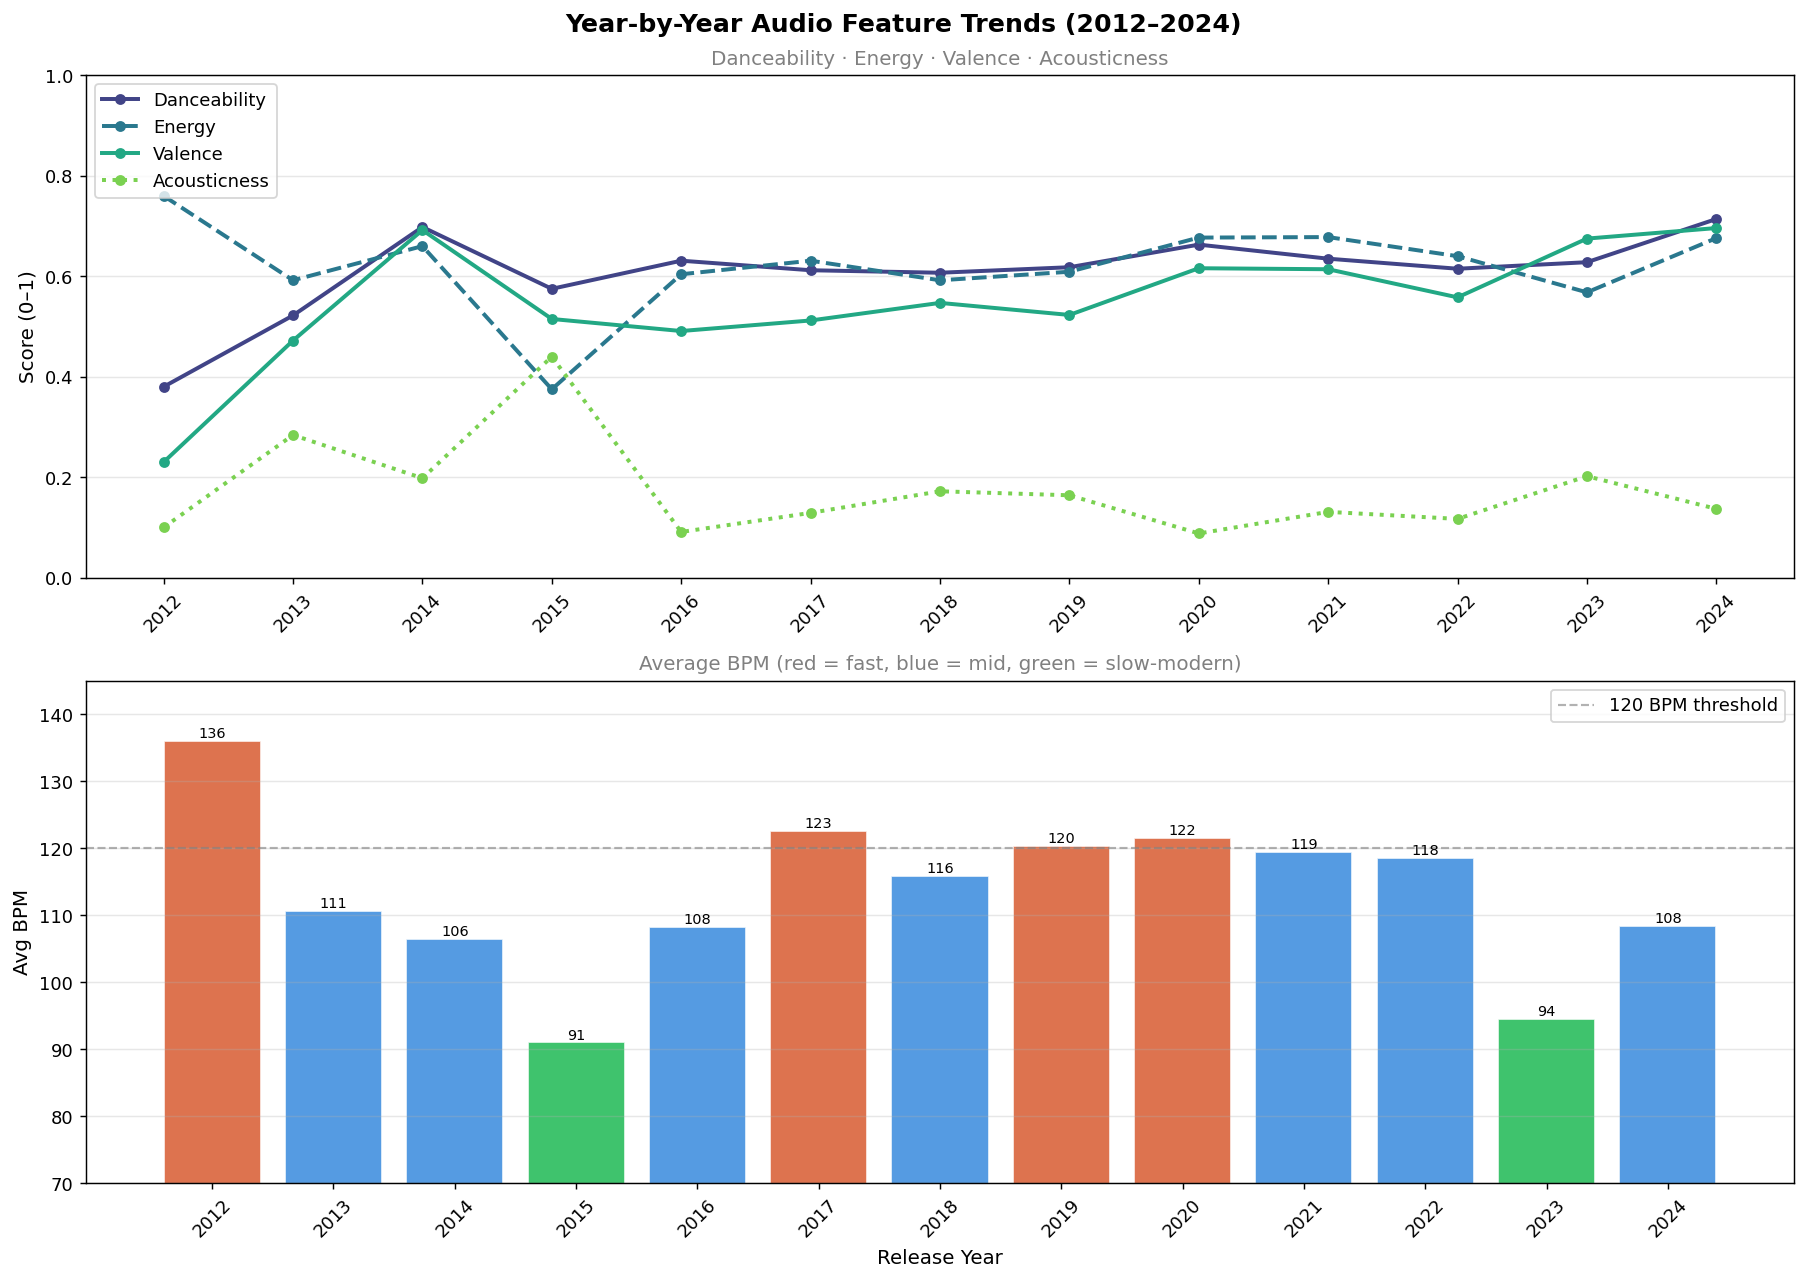

In [25]:
recent = df_at[df_at['release_year'] >= 2012].copy()
year_means = recent.groupby('release_year')[features + ['bpm']].mean().round(3)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Year-by-Year Audio Feature Trends (2012–2024)', fontsize=14, fontweight='bold')

ax = axes[0]
# Generate a general color palette using seaborn
general_colors = sns.color_palette('viridis', n_colors=len(features))

feat_styles = [
    ('danceability', general_colors[0], '-', 'Danceability'),
    ('energy',       general_colors[1], '--', 'Energy'),
    ('valence',      general_colors[2], '-', 'Valence'),
    ('acousticness', general_colors[3], ':', 'Acousticness'),
]
for feat, color, ls, label in feat_styles:
    ax.plot(year_means.index, year_means[feat], color=color, linestyle=ls,
            linewidth=2.2, marker='o', markersize=5, label=label)

ax.set_ylim(0, 1)
ax.set_ylabel('Score (0–1)', fontsize=11)
ax.set_xlabel('')
ax.legend(loc='upper left', fontsize=10)
ax.set_xticks(year_means.index)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)
ax.set_title('Danceability · Energy · Valence · Acousticness', fontsize=11, color='gray')

# Panel 2: BPM
ax2 = axes[1]
bpm_colors = ['#D85A30' if v > 120 else '#378ADD' if v > 105 else '#1DB954' for v in year_means['bpm']]
bars = ax2.bar(year_means.index, year_means['bpm'], color=bpm_colors, alpha=0.85, edgecolor='white')
ax2.axhline(120, color='gray', linestyle='--', lw=1.2, alpha=0.6, label='120 BPM threshold')
ax2.set_ylabel('Avg BPM', fontsize=11)
ax2.set_xlabel('Release Year', fontsize=11)
ax2.set_ylim(70, 145)
ax2.set_xticks(year_means.index)
ax2.tick_params(axis='x', rotation=45)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_title('Average BPM (red = fast, blue = mid, green = slow-modern)', fontsize=11, color='gray')
for bar, v in zip(bars, year_means['bpm']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v:.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

## 4. All-Time vs 2025 — Side-by-Side Comparison

In [26]:
alltime_means = df_at[features + ['bpm']].mean()
wrapped25_means = df_25[features + ['bpm']].mean()

comparison = pd.DataFrame({
    'All-Time Top 100': alltime_means,
    '2025 Wrapped Top 50': wrapped25_means,
}).round(3)
comparison['Change'] = (wrapped25_means - alltime_means).round(3)
comparison['Change %'] = ((wrapped25_means / alltime_means - 1) * 100).round(1).astype(str) + '%'

print('All-Time vs 2025 Wrapped')
display(comparison)

All-Time vs 2025 Wrapped


,All-Time Top 100,2025 Wrapped Top 50,Change,Change %
danceability,0.614,0.682,0.068,11.1%
energy,0.636,0.647,0.011,1.7%
valence,0.551,0.666,0.115,20.9%
acousticness,0.153,0.152,-0.001,-0.8%
bpm,115.780,109.800,-5.980,-5.2%


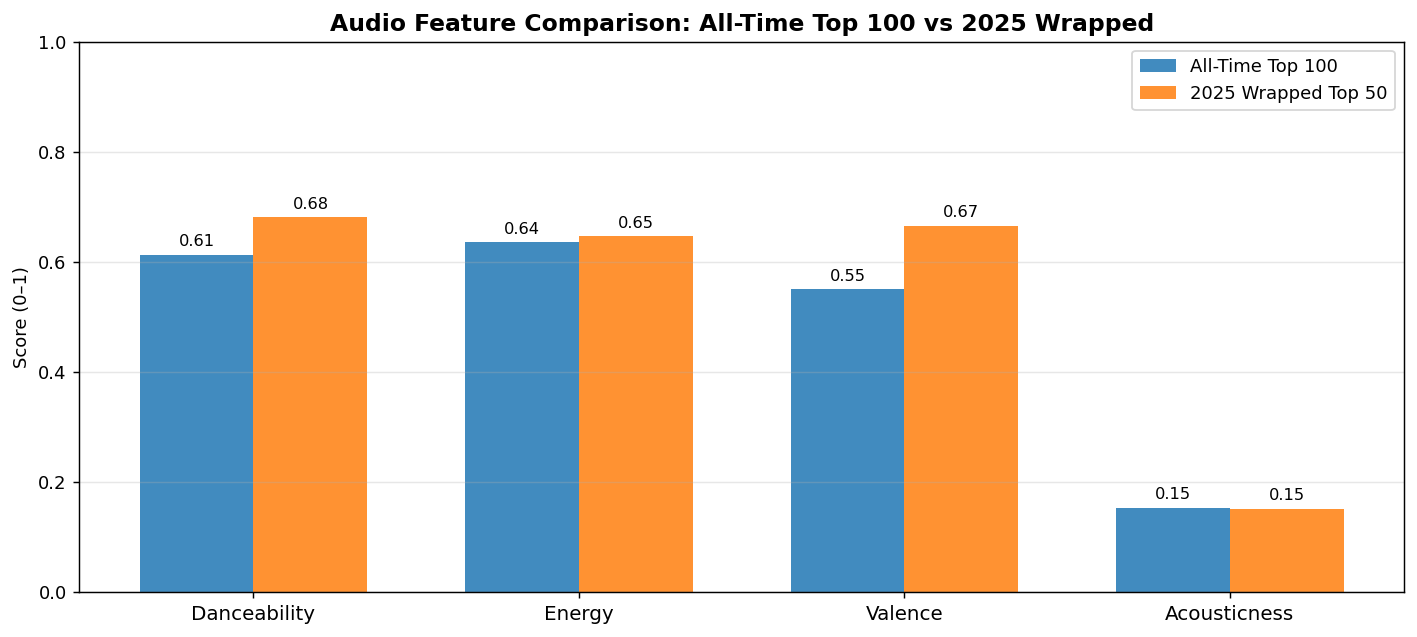

In [27]:
fig, ax = plt.subplots(figsize=(11, 5))

feat_labels = ['Danceability', 'Energy', 'Valence', 'Acousticness']
x = np.arange(len(feat_labels))
w = 0.35

b1 = ax.bar(x - w/2, alltime_means[features].values, w, label='All-Time Top 100',
            alpha=0.85)
b2 = ax.bar(x + w/2, wrapped25_means[features].values, w, label='2025 Wrapped Top 50',
            alpha=0.85)

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(feat_labels, fontsize=11)
ax.set_ylim(0, 1)
ax.set_ylabel('Score (0–1)')
ax.set_title('Audio Feature Comparison: All-Time Top 100 vs 2025 Wrapped', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Correlation: Which Features Drive Streams?

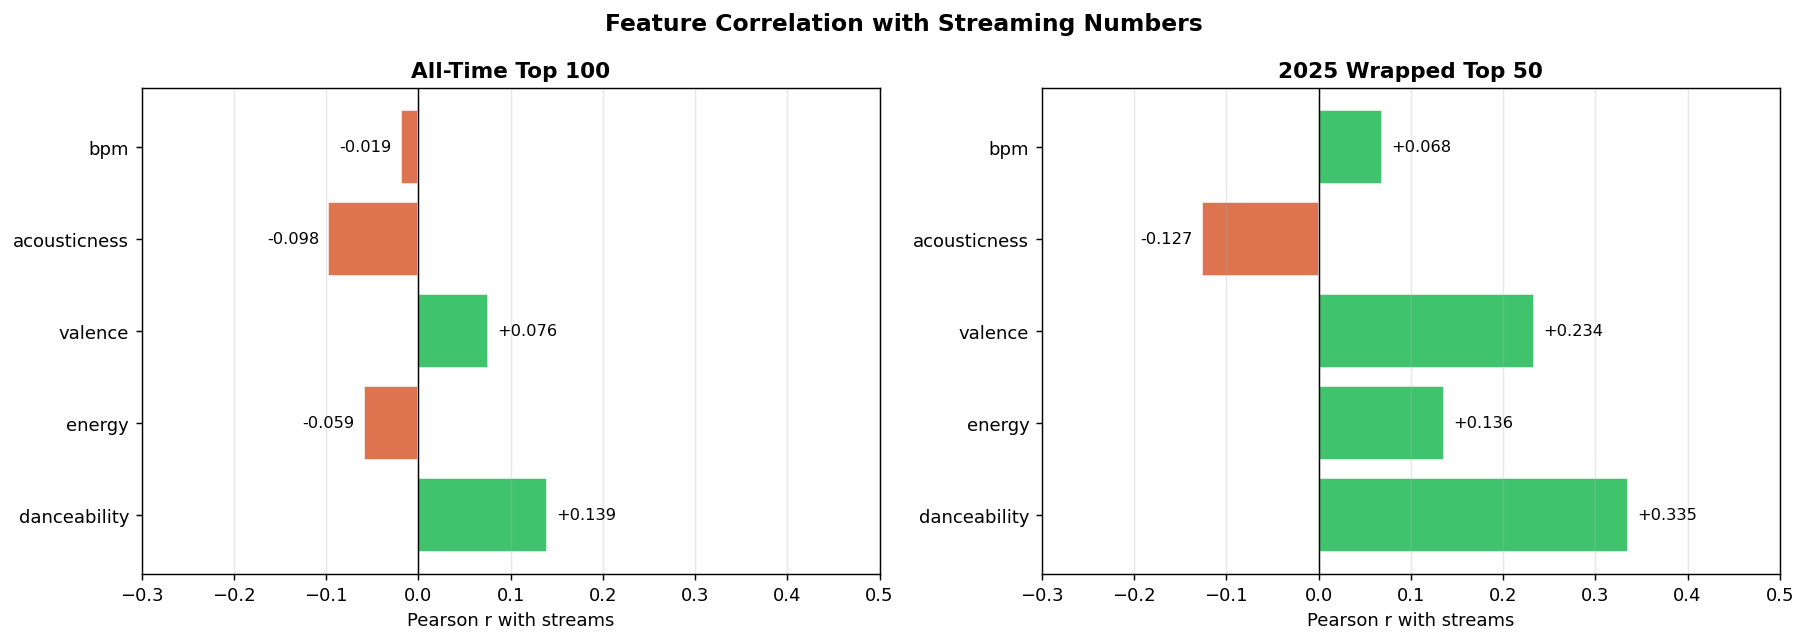


Key insight: Danceability is the strongest positive predictor of streams in 2025 (r=+0.335)


In [28]:
corr_at = df_at[features + ['bpm', 'total_streams_billions']].corr()['total_streams_billions'].drop('total_streams_billions')
corr_25 = df_25[features + ['bpm', 'streams_2025_billions']].corr()['streams_2025_billions'].drop('streams_2025_billions')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature Correlation with Streaming Numbers', fontsize=13, fontweight='bold')

for ax, corr, title in [
    (axes[0], corr_at, 'All-Time Top 100'),
    (axes[1], corr_25, '2025 Wrapped Top 50')
]:
    colors = ['#1DB954' if v > 0 else '#D85A30' for v in corr.values]
    bars = ax.barh(corr.index, corr.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Pearson r with streams')
    ax.set_xlim(-0.3, 0.5)
    ax.grid(axis='x', alpha=0.3)
    for bar, v in zip(bars, corr.values):
        ax.text(v + 0.01 if v >= 0 else v - 0.01, bar.get_y() + bar.get_height()/2,
                f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print('\nKey insight: Danceability is the strongest positive predictor of streams in 2025 (r=+0.335)')

## 6. Key Trend Summary

In [29]:
print('        HISTORICAL TREND SUMMARY')

dance_change = (wrapped25_means['danceability'] - alltime_means['danceability']) / alltime_means['danceability'] * 100
valence_change = (wrapped25_means['valence'] - alltime_means['valence']) / alltime_means['valence'] * 100
bpm_change = wrapped25_means['bpm'] - alltime_means['bpm']
acoustic_change = (wrapped25_means['acousticness'] - alltime_means['acousticness']) / alltime_means['acousticness'] * 100

print(f'\n Danceability: {dance_change:+.1f}% vs all-time avg')
print(f'\n Valence (positivity): {valence_change:+.1f}% vs all-time avg')
print(f'\n BPM: {bpm_change:+.1f} bpm vs all-time avg ({alltime_means["bpm"]:.0f} → {wrapped25_means["bpm"]:.0f})')
print(f'\n Acousticness: {acoustic_change:+.1f}% vs all-time avg')
print(f'\n Strongest stream predictor in 2025: Danceability (r={corr_25["danceability"]:+.3f})')


        HISTORICAL TREND SUMMARY

 Danceability: +11.1% vs all-time avg

 Valence (positivity): +20.9% vs all-time avg

 BPM: -6.0 bpm vs all-time avg (116 → 110)

 Acousticness: -0.8% vs all-time avg

 Strongest stream predictor in 2025: Danceability (r=+0.335)
